<a href="https://colab.research.google.com/github/albert-magarire/Leetcode-Solutions/blob/java-dsa/Albert_Magarire_MATH_213.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install aiohttp aiofiles tqdm pandas numpy matplotlib seaborn scikit-learn tensorflow

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "MovieGenre.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "neha1703/movie-genre-from-its-poster",
  file_path,
  pandas_kwargs={'encoding': 'latin1'}
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipython-input-3304402247.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'movie-genre-from-its-poster' dataset.


In [6]:
import os
import aiohttp
import aiofiles
import asyncio
import io
from PIL import Image
from tqdm.asyncio import tqdm

# Define the directory for saving images
IMAGE_DIR = '/content/images'
os.makedirs(IMAGE_DIR, exist_ok=True)

# Note: df must be defined in previous cells for this to work
df = df.drop_duplicates(subset=['imdbId'])
print(f'Cleaned shape: {df.shape}')

# Async Download Function
async def fetch_image(session, url, imdb_id):
    try:
        timeout = aiohttp.ClientTimeout(total=10)
        async with session.get(url, timeout=timeout) as response:
            if response.status == 200:
                content = await response.read()
                # Verify Image Integrity
                try:
                    img = Image.open(io.BytesIO(content))
                    img.verify()
                    async with aiofiles.open(os.path.join(IMAGE_DIR, f'{imdb_id}.jpg'), 'wb') as f:
                        await f.write(content)
                    return True
                except:
                    return False
            return False
    except:
        return False

async def download_main(df_subset):
    async with aiohttp.ClientSession() as session:
        tasks = []
        for _, row in df_subset.iterrows():
            if not os.path.exists(os.path.join(IMAGE_DIR, f'{row["imdbId"]}.jpg')):
                task = asyncio.create_task(fetch_image(session, row['Poster'], row['imdbId']))
                tasks.append(task)

        results = []
        # TQDM for progress tracking in async loop
        for f in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc='Downloading Images'):
            res = await f
            results.append(res)
    print(f'Downloaded {sum(results)} images successfully.')

# Execute Download
# NOTE: In Colab, await is top-level. In script, use asyncio.run()
await download_main(df)

Cleaned shape: (39515, 6)


Downloaded 8250 images successfully.


In [9]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Filter for existing files
df['file_path'] = df['imdbId'].apply(lambda x: os.path.join(IMAGE_DIR, f'{x}.jpg'))
df['exists'] = df['file_path'].apply(os.path.exists)
df_final = df[df['exists']].copy()

# Process Genres
df_final['genre_list'] = df_final['Genre'].apply(lambda x: str(x).split('|'))

# Binarize Labels
mlb = MultiLabelBinarizer()
y_matrix = mlb.fit_transform(df_final['genre_list'])
classes = mlb.classes_
print(f'Detected Classes: {classes}')

# Split Data
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=42)

# Data Generators
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from DataFrame
# Note: Class_mode='categorical' in Keras usually implies softmax/one-hot.
# For multi-label with flow_from_dataframe, providing a list of labels in y_col
# and class_mode='categorical' works if the list contains the string labels.
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=None,
    x_col='file_path',
    y_col='genre_list',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=list(classes),
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=None,
    x_col='file_path',
    y_col='genre_list',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=list(classes),
    shuffle=False # Crucial for evaluation alignment
)

Detected Classes: ['Action' 'Adventure' 'Animation' 'Biography' 'Comedy' 'Crime'
 'Documentary' 'Drama' 'Family' 'Fantasy' 'Film-Noir' 'History' 'Horror'
 'Music' 'Musical' 'Mystery' 'News' 'Romance' 'Sci-Fi' 'Short' 'Sport'
 'Talk-Show' 'Thriller' 'War' 'Western' 'nan']
Found 6600 validated image filenames belonging to 26 classes.
Found 1650 validated image filenames belonging to 26 classes.


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(num_classes, activation='sigmoid') # Use sigmoid for multi-label classification
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy', # Use binary_crossentropy for multi-label classification
                  metrics=['accuracy'])
    return model

model = build_model(len(classes))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,409,434 (169.41 MB)

 Trainable params: 44,409,434 (169.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2624 - loss: 0.2325

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


207/207 ━━━━━━━━━━━━━━━━━━━━ 966s 5s/step - accuracy: 0.2624 - loss: 0.2325 - val_accuracy: 0.2121 - val_loss: 0.2326
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 957s 5s/step - accuracy: 0.2771 - loss: 0.2273 - val_accuracy: 0.2624 - val_loss: 0.2287
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 963s 5s/step - accuracy: 0.2936 - loss: 0.2289 - val_accuracy: 0.3200 - val_loss: 0.2392
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 974s 5s/step - accuracy: 0.2955 - loss: 0.2277 - val_accuracy: 0.2764 - val_loss: 0.2323
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 956s 5s/step - accuracy: 0.3044 - loss: 0.2256 - val_accuracy: 0.2285 - val_loss: 0.2314
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 956s 5s/step - accuracy: 0.2908 - loss: 0.2231 - val_accuracy: 0.2552 - val_loss: 0.2274
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 983s 5s/step - accuracy: 0.3123 - loss: 0.2215 - val_accuracy: 0.3133 - val_loss: 0.2283
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 959s 5s/step - accuracy: 0.3098 - loss: 0.2225 - val_accuracy: 0.222

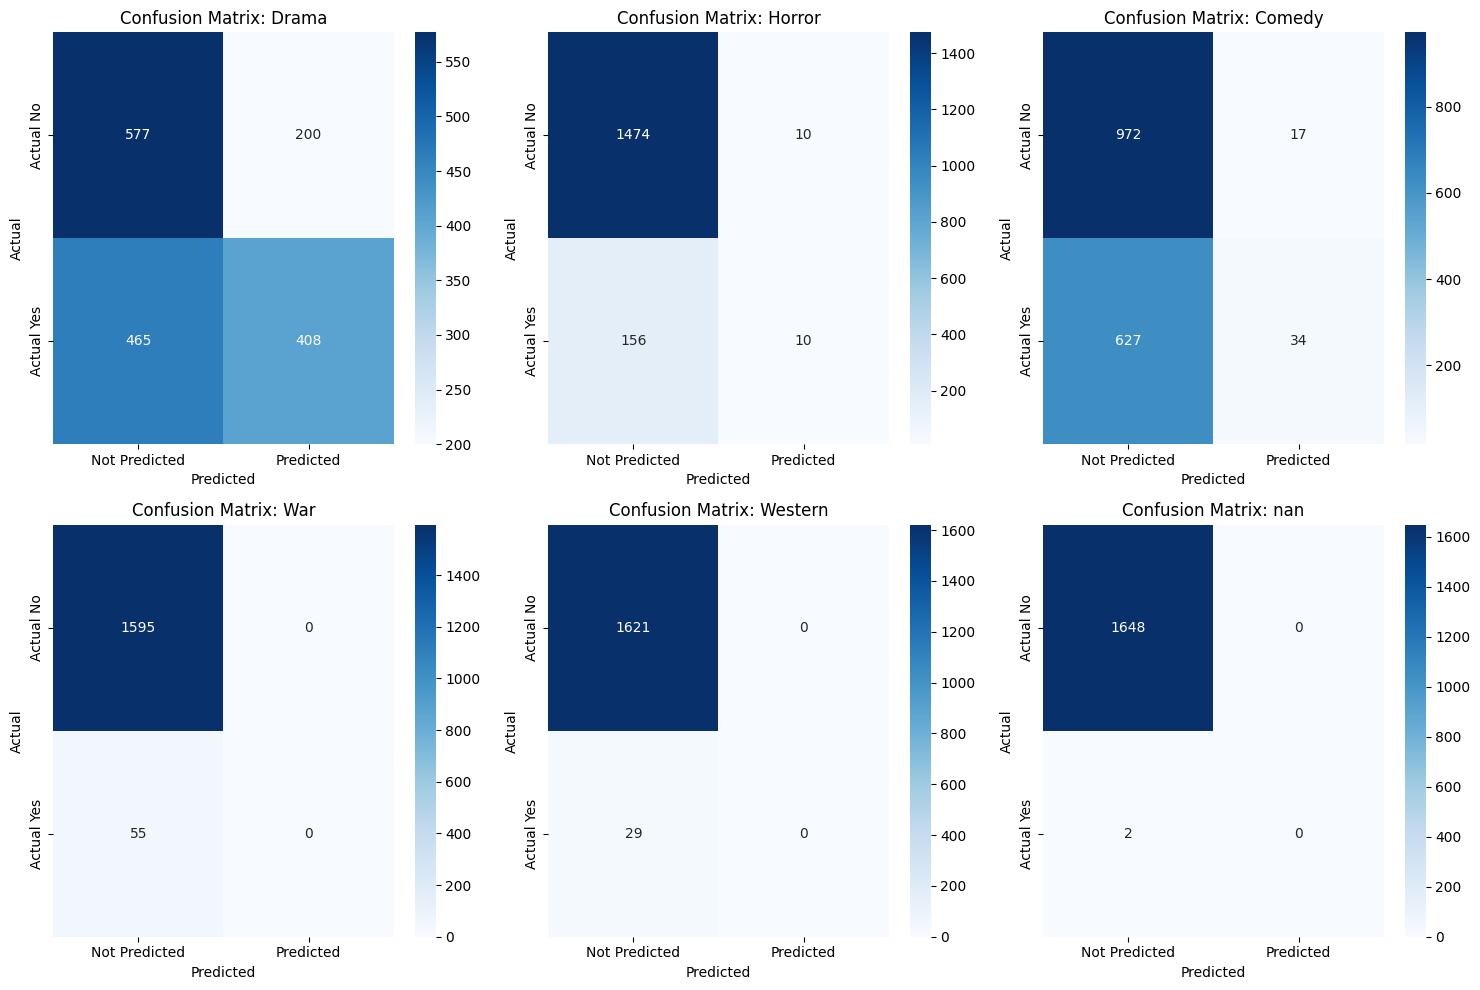

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import numpy as np

# Train the model
# Assuming 'model' is defined from the previous cell
EPOCHS = 10 # You can adjust the number of epochs

# Using test_generator.samples for steps_per_epoch is incorrect. It should be train_generator.samples.
# The corrected approach for steps_per_epoch for training is typically len(train_generator)
# And for validation_steps it's len(test_generator)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=len(test_generator)
)

# Make predictions on the test set
predictions = model.predict(test_generator, steps=len(test_generator))

# Convert predictions to binary (0 or 1) based on a threshold (e.g., 0.5)
pred_bool = (predictions > 0.5).astype(int)

# Get true labels from the test generator
y_true = np.zeros((test_generator.samples, len(classes)))
i = 0
for batch_x, batch_y in test_generator:
    # Get the true labels for the current batch
    start_idx = i * BATCH_SIZE
    end_idx = min((i + 1) * BATCH_SIZE, test_generator.samples)
    y_true[start_idx:end_idx] = batch_y[:end_idx-start_idx]
    i += 1
    if i == len(test_generator): # Stop after all batches are processed
        break

# 1. Classification Report (Precision/Recall)
report = classification_report(y_true, pred_bool, target_names=classes, output_dict=True, zero_division=0)
print(classification_report(y_true, pred_bool, target_names=classes, zero_division=0))

# 2. Hardest vs Easiest Genres
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in classes}
sorted_genres = sorted(f1_scores.items(), key=lambda item: item[1], reverse=True)

print('\n--- EASIEST GENRES (Highest F1) ---')
for g, s in sorted_genres[:5]:
    print(f'{g}: {s:.4f}')

print('\n--- HARDEST GENRES (Lowest F1) ---')
for g, s in sorted_genres[-5:]:
    print(f'{g}: {s:.4f}')

# 3. Confusion Matrix (Multi-label)
mcm = multilabel_confusion_matrix(y_true, pred_bool)

# Visualize Top 3 Easiest and Top 3 Hardest
genres_to_plot_names = [g[0] for g in sorted_genres[:3]] + [g[0] for g in sorted_genres[-3:]]
indices = [list(classes).index(g) for g in genres_to_plot_names]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    cm = mcm[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {classes[idx]}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    # Optionally, set tick labels if they represent specific classes/binary outcomes
    axes[i].set_xticklabels(['Not Predicted', 'Predicted'])
    axes[i].set_yticklabels(['Actual No', 'Actual Yes'], rotation=90)

plt.tight_layout()
plt.show()